In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\User\OneDrive\Documents\Brazilian-Ecommerce-Cleaned.xlsx", parse_dates=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
print("Done!")

Done!


Dataset confirmed: 113,390 rows loaded.

Top 10 Best Performing States (Most Early Deliveries):
    customer_state  avg_delay_days
0              AC      -21.282609
20             RO      -19.890909
2              AM      -19.820359
3              AP      -18.650602
21             RR      -18.500000
12             MT      -14.441425
13             PA      -14.266106
22             RS      -14.199714
19             RN      -13.632432
17             PR      -13.488428


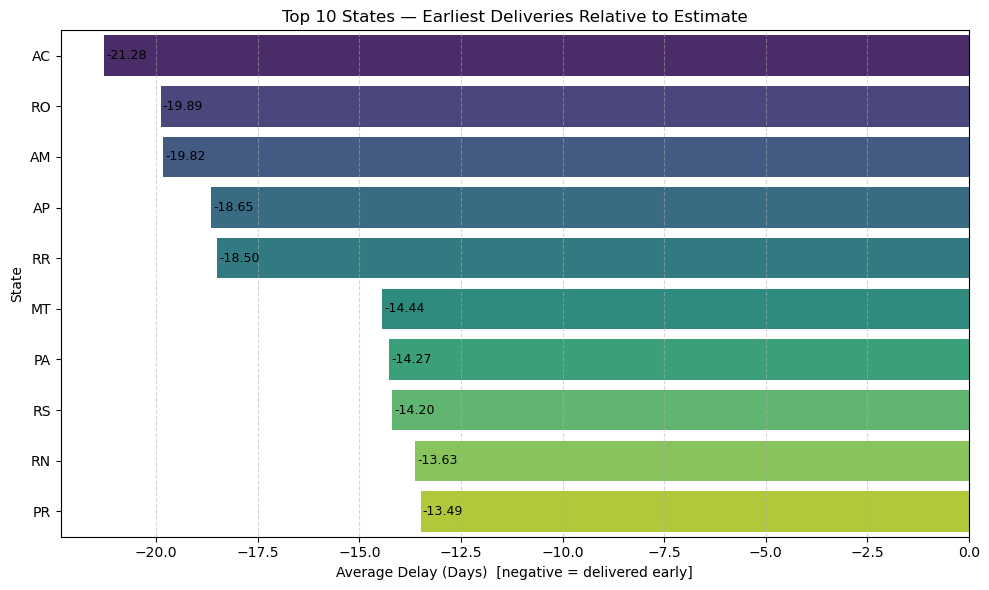


Top 10 Worst Performing States (Least Early Deliveries):
    customer_state  avg_delay_days
1              AL       -8.592677
9              MA       -9.798267
24             SE       -9.958333
7              ES      -10.619755
4              BA      -10.976419
25             SP      -11.230776
11             MS      -11.259080
5              CE      -11.361673
16             PI      -11.485348
23             SC      -11.647921


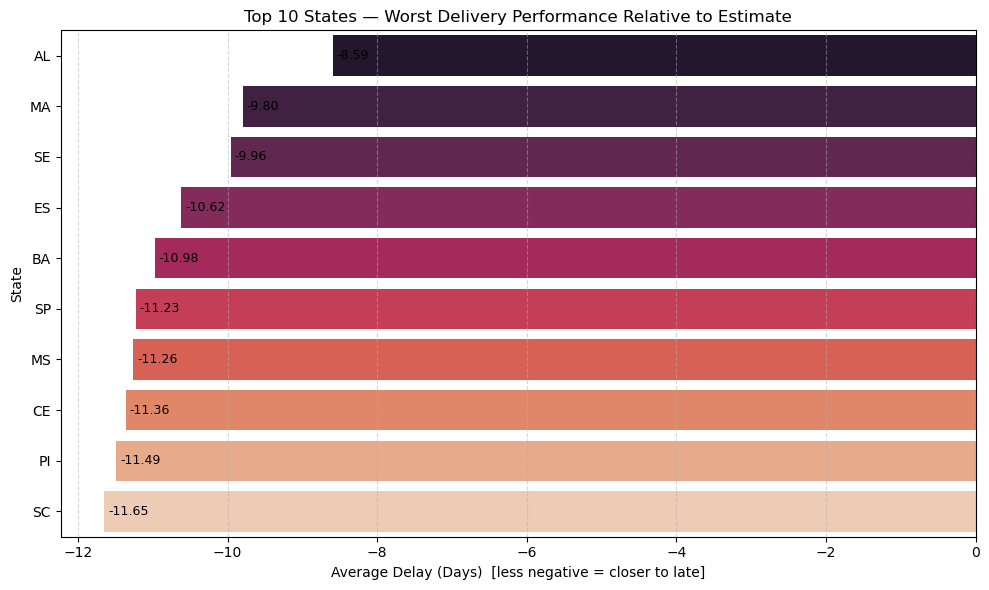


Top 10 States — Highest Delay Rate:
    customer_state  delay_rate
1              AL    0.212815
9              MA    0.181931
24             SE    0.158854
16             PI    0.139194
5              CE    0.130904
4              BA    0.118165
18             RJ    0.116443
21             RR    0.113636
13             PA    0.112979
14             PB    0.112378


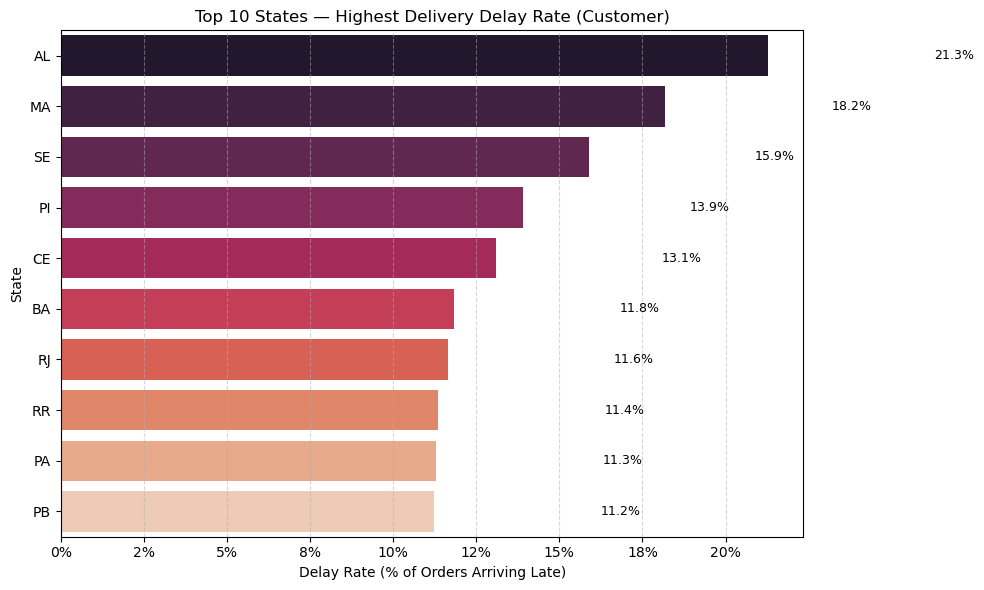


Top 10 States — Highest Avg Freight Value:
    customer_state  avg_freight_value
21             RR          43.777500
14             PB          43.725195
20             RO          41.264473
0              AC          40.209022
26             TO          40.092485
16             PI          39.248883
9              MA          38.572970
24             SE          36.647135
1              AL          35.824645
13             PA          35.432269


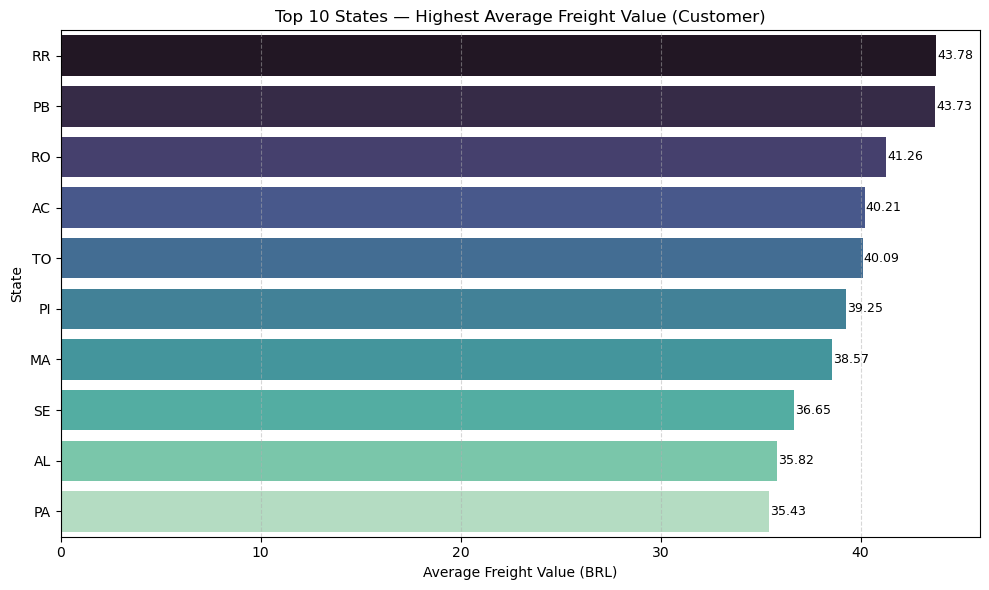


North vs Southeast — three metrics:
       region  avg_delivery_days  avg_freight_value  delay_rate
0      North          22.050436          37.101678    0.086324
1  Southeast          10.241580          17.433537    0.058741


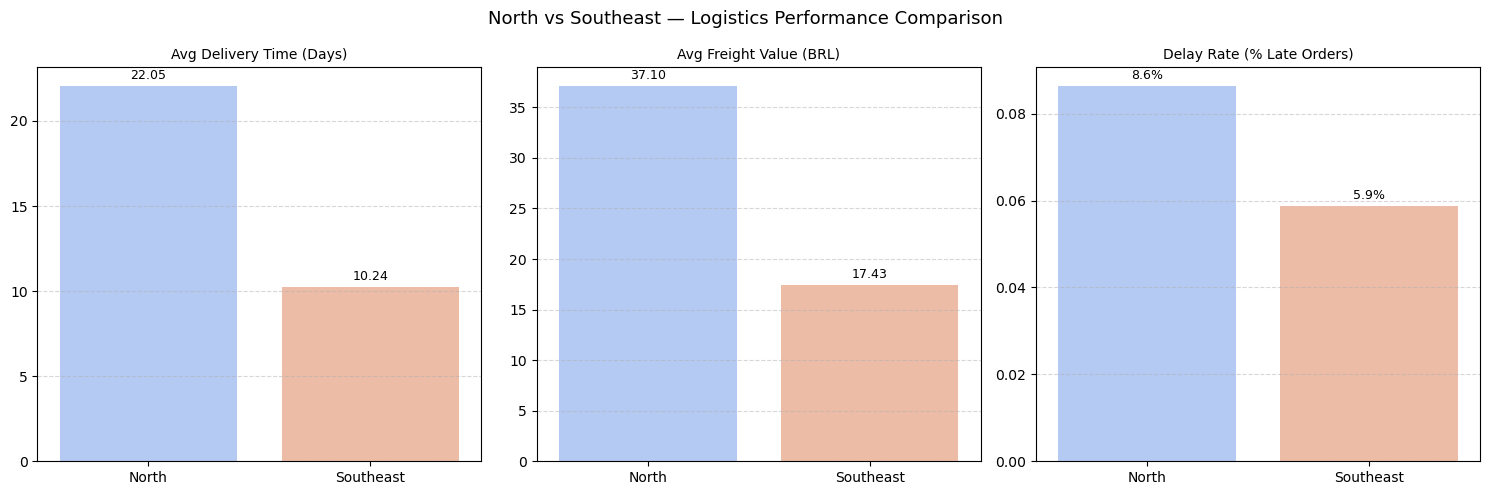


Top 10 Seller States — Highest Avg Delivery Time:
    seller_state  avg_delivery_days
0            AM          47.333333
6            MA          17.288177
2            CE          16.969697
17           RO          16.928571
9            MT          14.232877
1            BA          13.450663
13           PI          13.272727
10           PA          13.125000
19           SC          12.983894
14           PR          12.874728


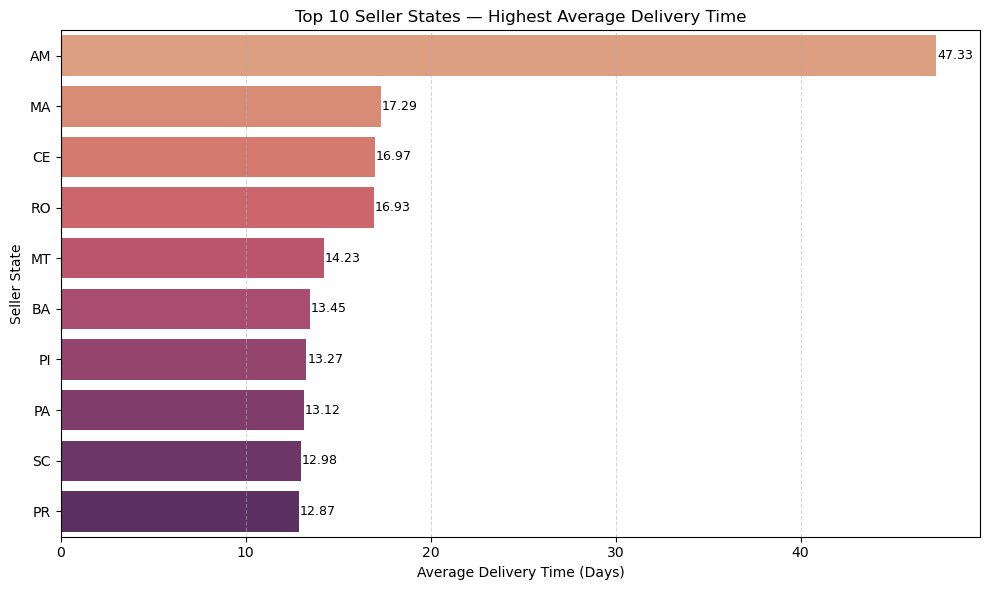


Top 10 States by Seller Order Volume:
   seller_state  order_count
21           SP        80870
7            MG         8815
14           PR         8733
15           RJ         4798
19           SC         4160
18           RS         2203
3            DF          919
1            BA          679
5            GO          527
12           PE          462


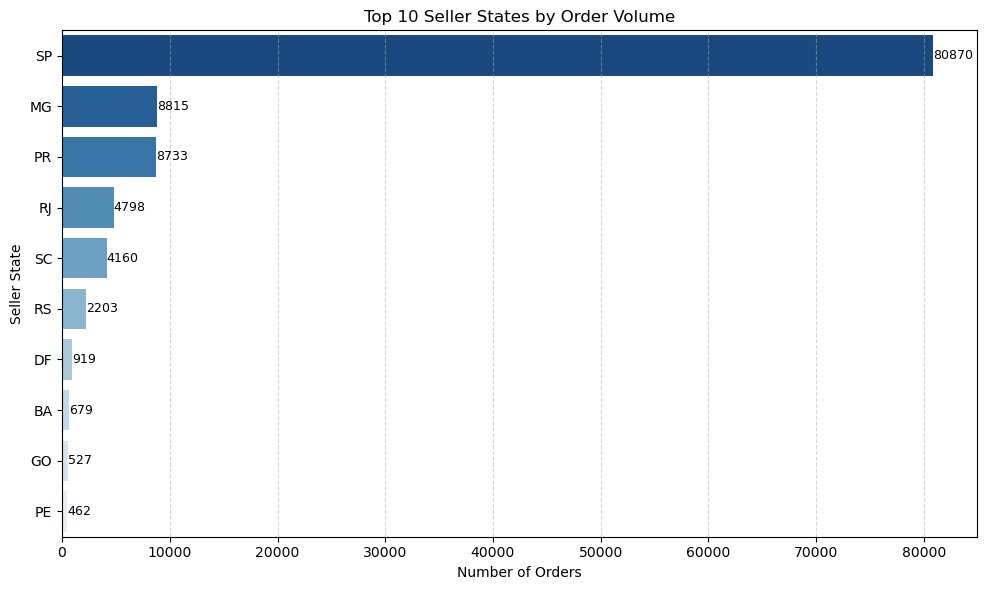


Distance Impact:
    distance_proxy  delay_days             Type
0               0  -10.471527       Same State
1               1  -12.940130  Different State


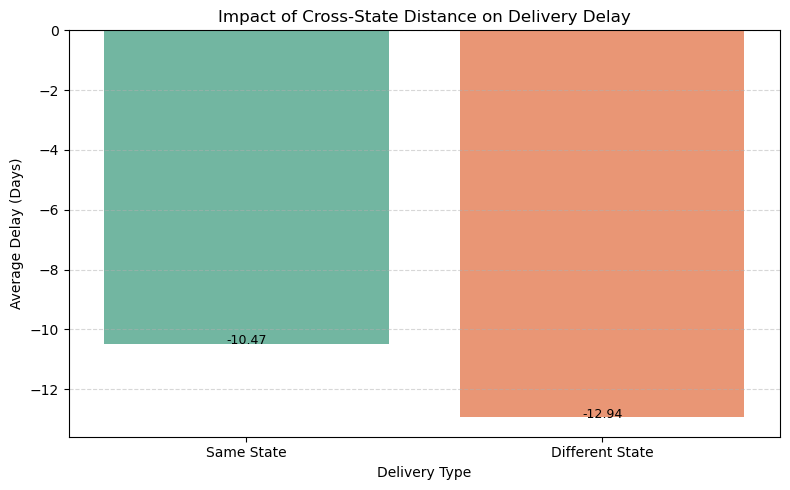


All Module 2 graphs and exports saved successfully!


In [6]:
# ── DATASET INTEGRITY CHECK ───────────────────────────────────────────────────
assert len(df) > 100000, (
    f"Expected full dataset (113,390 rows) but got {len(df)} rows. "
    f"Make sure df is not the Module 1 sample."
)
print(f"Dataset confirmed: {len(df):,} rows loaded.")

output_dir = Path(r"D:\Olist_Analysis_Project\Outputs\Module2")
output_dir.mkdir(parents=True, exist_ok=True)

# ── PREPROCESSING ─────────────────────────────────────────────────────────────

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
df[date_cols] = df[date_cols].apply(pd.to_datetime)

df["delay_days"]      = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["delivery_days"]   = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["processing_time"] = (df["order_approved_at"]             - df["order_purchase_timestamp"]).dt.days
df["shipping_time"]   = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.days
df["distance_proxy"]  = (df["seller_state"] != df["customer_state"]).astype(int)

# ── REGION DEFINITION ─────────────────────────────────────────────────────────

north     = ["AM", "PA", "RO", "RR", "AP", "AC", "TO"]
southeast = ["SP", "RJ", "MG", "ES"]

df["region"] = df["customer_state"].apply(
    lambda x: "North" if x in north else ("Southeast" if x in southeast else "Other")
)

# ── HELPER ────────────────────────────────────────────────────────────────────

import matplotlib.ticker as mtick

def add_labels(ax, values, orient="h", fmt=".2f"):
    for i, v in enumerate(values):
        label = f"{v:{fmt}}"
        if orient == "h":
            ax.text(v + 0.05, i, label, va="center", ha="left", fontsize=9)
        else:
            ax.text(i, v + max(values) * 0.01, label, ha="center", va="bottom", fontsize=9)

# ── CUSTOMER-STATE AGGREGATIONS ───────────────────────────────────────────────

customer_agg = (
    df.groupby("customer_state")
    .agg(
        avg_delay_days    = ("delay_days",    "mean"),   # ← back to delay_days for Graph 1
        avg_delivery_days = ("delivery_days", "mean"),   # kept for context if needed
        avg_freight_value = ("freight_value",  "mean"),
        delay_rate        = ("delay_days",      lambda x: (x > 0).mean()),
        order_count       = ("delay_days",      "count")
    )
    .reset_index()
    .sort_values("avg_delay_days", ascending=False)      # ← least negative first (MA), most negative last (SP)
)

# ── SELLER-STATE AGGREGATIONS ─────────────────────────────────────────────────

seller_agg = (
    df.groupby("seller_state")
    .agg(
        avg_delivery_days = ("delivery_days", "mean"),
        avg_freight_value = ("freight_value",  "mean"),
        delay_rate        = ("delay_days",      lambda x: (x > 0).mean()),
        order_count       = ("delay_days",      "count")
    )
    .reset_index()
    .sort_values("avg_delivery_days", ascending=False)
)

# ── GRAPH 1: TOP 10 STATES — AVG DELIVERY TIME (customer) ────────────────────

# ── GRAPH 1: TOP 10 BEST PERFORMING STATES (most early) ──────────────────────

best_states = customer_agg.sort_values("avg_delay_days", ascending=True).head(10)  # most negative first
print("\nTop 10 Best Performing States (Most Early Deliveries):\n",
      best_states[["customer_state", "avg_delay_days"]])

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=best_states, x="avg_delay_days", y="customer_state",
                 hue="customer_state", palette="viridis", legend=False)
plt.title("Top 10 States — Earliest Deliveries Relative to Estimate")
plt.xlabel("Average Delay (Days)  [negative = delivered early]")
plt.ylabel("State")
plt.grid(axis="x", linestyle="--", alpha=0.5)
add_labels(ax, best_states["avg_delay_days"].values, orient="h")
plt.tight_layout()
plt.savefig(output_dir / "customer_best_delivery.png", dpi=300)
plt.show()

# ── GRAPH 1B: TOP 10 WORST PERFORMING STATES (least early) ───────────────────

worst_states = customer_agg.sort_values("avg_delay_days", ascending=False).head(10)  # least negative first
print("\nTop 10 Worst Performing States (Least Early Deliveries):\n",
      worst_states[["customer_state", "avg_delay_days"]])

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=worst_states, x="avg_delay_days", y="customer_state",
                 hue="customer_state", palette="rocket", legend=False)
plt.title("Top 10 States — Worst Delivery Performance Relative to Estimate")
plt.xlabel("Average Delay (Days)  [less negative = closer to late]")
plt.ylabel("State")
plt.grid(axis="x", linestyle="--", alpha=0.5)
add_labels(ax, worst_states["avg_delay_days"].values, orient="h")
plt.tight_layout()
plt.savefig(output_dir / "customer_worst_delivery.png", dpi=300)
plt.show()
# ── GRAPH 2: TOP 10 STATES — DELAY RATE (customer) ───────────────────────────

top_delay_rate = customer_agg.sort_values("delay_rate", ascending=False).head(10)
print("\nTop 10 States — Highest Delay Rate:\n", top_delay_rate[["customer_state","delay_rate"]])

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_delay_rate, x="delay_rate", y="customer_state",
                 hue="customer_state", palette="rocket", legend=False)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.title("Top 10 States — Highest Delivery Delay Rate (Customer)")
plt.xlabel("Delay Rate (% of Orders Arriving Late)")
plt.ylabel("State")
plt.grid(axis="x", linestyle="--", alpha=0.5)
add_labels(ax, top_delay_rate["delay_rate"].values, orient="h", fmt=".1%")
plt.tight_layout()
plt.savefig(output_dir/"customer_delay_rate.png", dpi=300)
plt.show()

# ── GRAPH 3: TOP 10 STATES — AVG FREIGHT VALUE (customer) ────────────────────

top_freight = customer_agg.sort_values("avg_freight_value", ascending=False).head(10)
print("\nTop 10 States — Highest Avg Freight Value:\n", top_freight[["customer_state","avg_freight_value"]])

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_freight, x="avg_freight_value", y="customer_state",
                 hue="customer_state", palette="mako", legend=False)
plt.title("Top 10 States — Highest Average Freight Value (Customer)")
plt.xlabel("Average Freight Value (BRL)")
plt.ylabel("State")
plt.grid(axis="x", linestyle="--", alpha=0.5)
add_labels(ax, top_freight["avg_freight_value"].values, orient="h")
plt.tight_layout()
plt.savefig(output_dir/"customer_freight_value.png", dpi=300)
plt.show()

# ── GRAPH 4: NORTH vs SOUTHEAST — THREE-METRIC COMPARISON ────────────────────

region_metrics = (
    df[df["region"] != "Other"]
    .groupby("region")
    .agg(
        avg_delivery_days = ("delivery_days", "mean"),
        avg_freight_value = ("freight_value",  "mean"),
        delay_rate        = ("delay_days",      lambda x: (x > 0).mean())
    )
    .reset_index()
)
print("\nNorth vs Southeast — three metrics:\n", region_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("North vs Southeast — Logistics Performance Comparison", fontsize=13)

metrics = [
    ("avg_delivery_days", "Avg Delivery Time (Days)",   "coolwarm"),
    ("avg_freight_value", "Avg Freight Value (BRL)",     "coolwarm"),
    ("delay_rate",        "Delay Rate (% Late Orders)",  "coolwarm"),
]

for ax, (col, label, palette) in zip(axes, metrics):
    sns.barplot(data=region_metrics, x="region", y=col,
                hue="region", palette=palette, legend=False, ax=ax)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    vals = region_metrics[col].values
    fmt = ".1%" if col == "delay_rate" else ".2f"
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.01, f"{v:{fmt}}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(output_dir/"region_comparison_three_metrics.png", dpi=300)
plt.show()

# ── GRAPH 5: TOP 10 SELLER STATES — AVG DELIVERY TIME ────────────────────────

top_seller = seller_agg.head(10)
print("\nTop 10 Seller States — Highest Avg Delivery Time:\n", top_seller[["seller_state","avg_delivery_days"]])

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_seller, x="avg_delivery_days", y="seller_state",
                 hue="seller_state", palette="flare", legend=False)
plt.title("Top 10 Seller States — Highest Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Seller State")
plt.grid(axis="x", linestyle="--", alpha=0.5)
add_labels(ax, top_seller["avg_delivery_days"].values, orient="h")
plt.tight_layout()
plt.savefig(output_dir/"seller_delivery_time.png", dpi=300)
plt.show()

# ── SELLER CONCENTRATION CHECK ────────────────────────────────────────────────

seller_concentration = (
    df.groupby("seller_state")
    .size()
    .reset_index(name="order_count")
    .sort_values("order_count", ascending=False)
    .head(10)
)

print("\nTop 10 States by Seller Order Volume:")
print(seller_concentration)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=seller_concentration, x="order_count", y="seller_state",
                 hue="seller_state", palette="Blues_r", legend=False)
plt.title("Top 10 Seller States by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Seller State")
plt.grid(axis="x", linestyle="--", alpha=0.5)
add_labels(ax, seller_concentration["order_count"].values, orient="h", fmt=".0f")
plt.tight_layout()
plt.savefig(output_dir / "seller_concentration.png", dpi=300)
plt.show()

# ── GRAPH 6: DISTANCE PROXY IMPACT ───────────────────────────────────────────
# Kept here as a supplementary geographic insight since distance_proxy
# is derived from seller_state vs customer_state — relevant to Module 2.
# Its primary role as a Random Forest feature is in Module 1.

distance_delay = df.groupby("distance_proxy")["delay_days"].mean().reset_index()
distance_delay["Type"] = distance_delay["distance_proxy"].map({0: "Same State", 1: "Different State"})
print("\nDistance Impact:\n", distance_delay)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=distance_delay, x="Type", y="delay_days",
                 hue="Type", palette="Set2", legend=False)
plt.title("Impact of Cross-State Distance on Delivery Delay")
plt.xlabel("Delivery Type")
plt.ylabel("Average Delay (Days)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
add_labels(ax, distance_delay["delay_days"].values, orient="v")
plt.tight_layout()
plt.savefig(output_dir/"distance_impact.png", dpi=300)
plt.show()

print("\nAll Module 2 graphs and exports saved successfully!")